In [92]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot_images_with_detections(img_folder, detect_folder_list, img_list, 
                                img_label_list=None, row_name_list=None, IOU_dict=None,
                                save_path=None, dpi=1200):
    """
    Plots images in a grid where the first row contains original images, 
    and subsequent rows contain detection results from different folders.

    Args:
        img_folder (str): Path to the folder containing original images.
        detect_folder_list (list): List of paths to folders with detected results.
        img_list (list): List of image names (without suffix) to plot.
        img_label_list (list, optional): Labels for each image (displayed as titles).
        row_name_list (list, optional): Names for each row, displayed on the left.
        IOU_dict (dict, optional): Dictionary where keys are row indices (as strings) 
                                   and values are lists of IoU values for each image.
    """
    num_rows = 1 + len(detect_folder_list)  # 1 row for original images + detection results
    num_cols = len(img_list)  # Number of images to plot

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(3 * num_cols, 3 * num_rows))

    if num_rows == 1:
        axes = np.expand_dims(axes, axis=0)  # Ensure axes is always 2D for consistent indexing

    for col, img_name in enumerate(img_list):
        # Read and plot the original image
        img_path = os.path.join(img_folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Image {img_path} not found.")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, col].imshow(img)
        axes[0, col].axis("off")

        # Set the title using img_label_list if provided
        title_text = img_label_list[col] if img_label_list else img_name
        axes[0, col].set_title(title_text, fontsize=24)

        # Read and plot detection results from each folder
        for row, detect_folder in enumerate(detect_folder_list, start=1):
            detect_img_path = os.path.join(detect_folder, img_name)
            detect_img = cv2.imread(detect_img_path)
            if detect_img is None:
                print(f"Warning: Detection result {detect_img_path} not found.")
                axes[row, col].axis("off")
                continue
            detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(detect_img)
            axes[row, col].axis("off")

            # Display IoU values if provided
            row_key = str(row)  # Convert row index to string to match IOU_dict keys
            if IOU_dict and row_key in IOU_dict and col < len(IOU_dict[row_key]):
                iou_value = IOU_dict[row_key][col]
                axes[row, col].text(
                    0.95, 0.05, f"{iou_value:.3f}", color="white", fontsize=20, 
                    ha="right", va="bottom", transform=axes[row, col].transAxes,
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')
                )

    # Add row labels to the left-most column
    if row_name_list:
        for row in range(num_rows):
            axes[row, 0].annotate(row_name_list[row], xy=(-0.05, 0.5), xycoords='axes fraction',
                                  fontsize=24, ha='right', va='center', rotation=90)

    plt.tight_layout()

    # Save the figure if save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved at {save_path}")

    plt.show()


def compute_IOU_list(folder_list, img_list):
    res = {}
    for i in range(len(folder_list) - 1):
        iou_list = []
        for img_name in img_list:
            img1 = cv2.imread(folder_list[0] + img_name, cv2.IMREAD_GRAYSCALE)
            img2 = cv2.imread(folder_list[i+1] + img_name, cv2.IMREAD_GRAYSCALE)
            binary1, binary2 = img1 > 0, img2 > 0
            intersection = np.logical_and(binary1, binary2)
            union = np.logical_or(binary1, binary2)
            iou = np.sum(intersection) / np.sum(union)
            iou_list.append(iou)
        res[str(i + 2)] = iou_list
    return res

Figure saved at /home/weiwang/ResearchProjects/mmsegmentation/BenchPlots/BenchMarkDemo.jpg


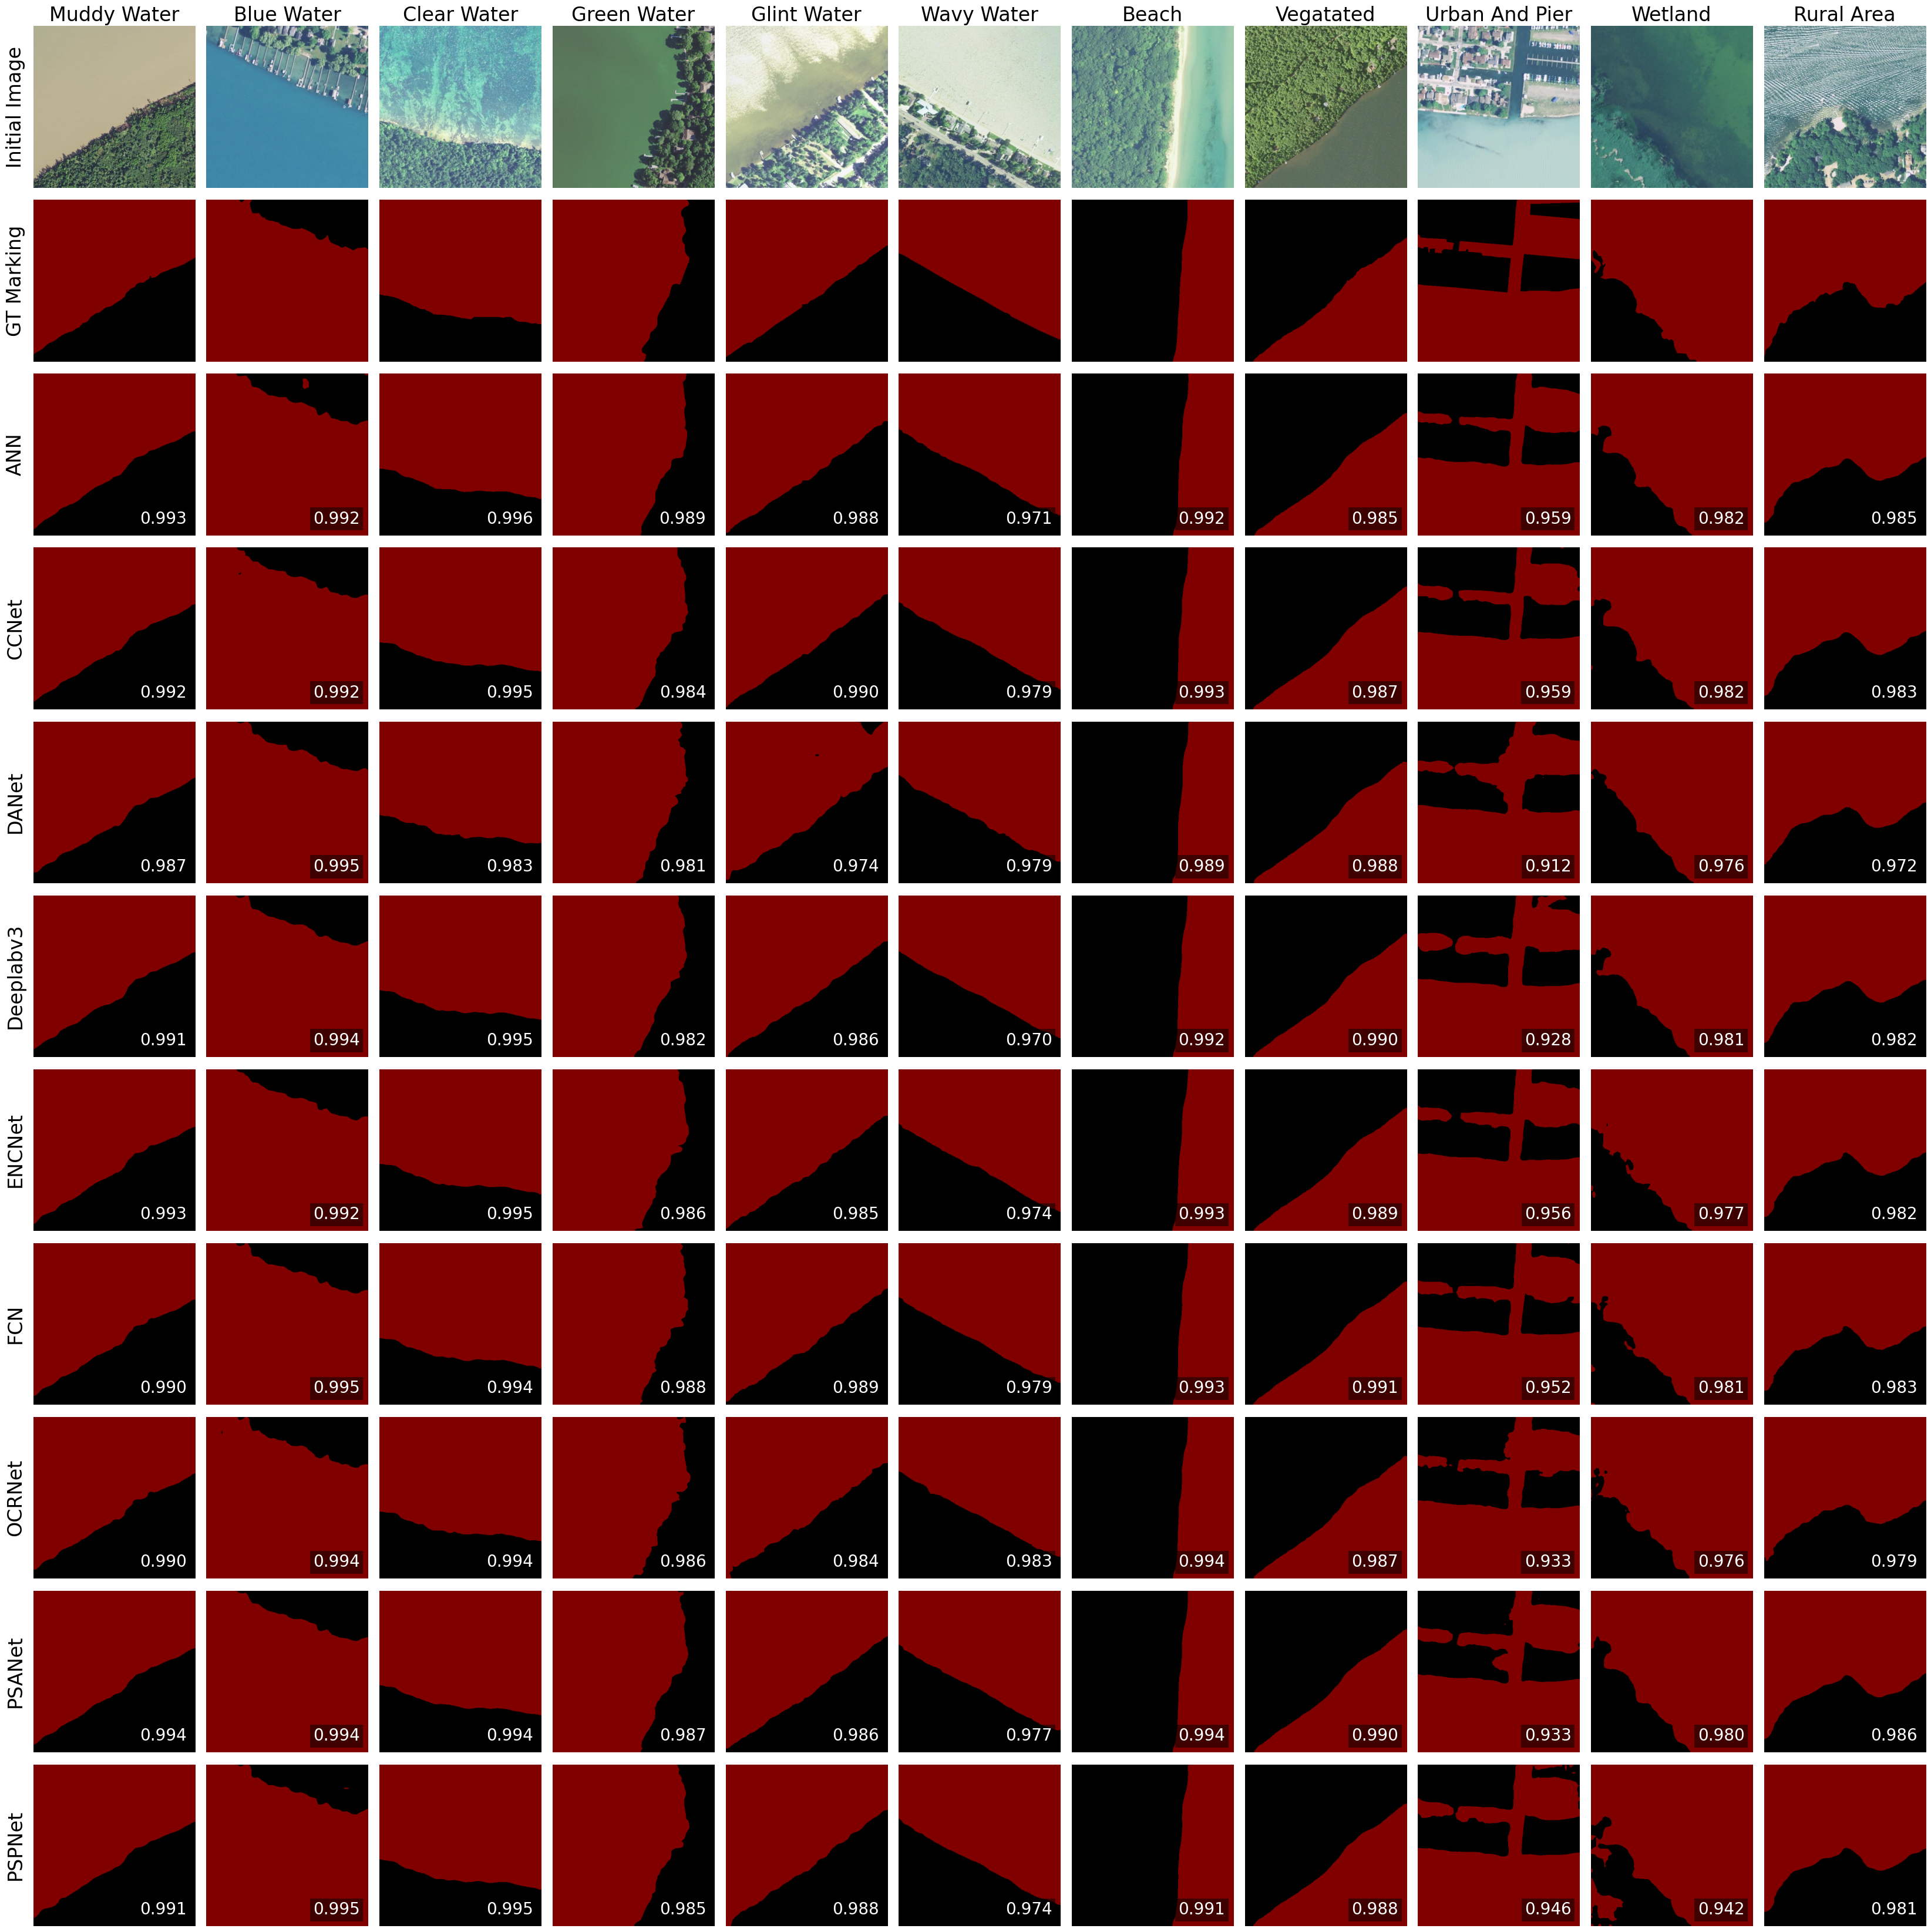

In [96]:
# Example usage
save_path = "/home/weiwang/ResearchProjects/mmsegmentation/BenchPlots/"
os.makedirs(save_path, exist_ok=True)
img_folder = "/home/weiwang/ResearchProjects/mmsegmentation/test_set/img/"
detect_folder_list = ['/home/weiwang/ResearchProjects/mmsegmentation/test_set/GT_label/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/ANN_result/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/CCNet_result/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/DaNet_result/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/Deeplabv3_result/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/ENCNet_result/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/FCN_result/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/OCR_result/',
                      '/home/weiwang/ResearchProjects/mmsegmentation/test_set/PSA_result/',
                        '/home/weiwang/ResearchProjects/mmsegmentation/test_set/PSP_result/',
                        ] 
                      
img_list = ["img_829.png", "img_15034.png", "img_2034.png", "img_19771.png", "img_5318.png",\
    "img_154.png", "img_8644.png", "img_4677.png", "img_7794.png", "img_19542.png", "img_10178.png"]

img_name_list = ["Muddy Water", "Blue Water", "Clear Water", "Green Water", "Glint Water",\
    "Wavy Water", "Beach", "Vegatated", "Urban And Pier", "Wetland", "Rural Area"]

row_name_list = ["Initial Image", "GT Marking", "ANN", "CCNet", "DANet", "Deeplabv3", "ENCNet", "FCN", "OCRNet", "PSANet", "PSPNet"]
iou_dict = compute_IOU_list(detect_folder_list, img_list)
plot_images_with_detections(img_folder, detect_folder_list, img_list, img_label_list=img_name_list, row_name_list=row_name_list, IOU_dict=iou_dict, save_path = save_path + "BenchMarkDemo.jpg", dpi=500)